# Phase 4c - Capacity-Normalized SOH External Validation

**Question.** Can Phase 4 be rescued by removing the absolute capacity-scale
mismatch between Luh/Blank 18650 cells and Kirkaldy LG M50T 21700 cells?

This notebook retrains a scale-free LSTM on Luh/Blank using:

- `SOH = Q / Q0`
- `Re_norm = Re / Re0`

Then it evaluates frozen transfer to Kirkaldy using BOL-seeded autoregressive
rollout in normalized space. It also converts SOH predictions back to capacity:

- `Q_pred = SOH_pred * Q0`

**Inputs to attach in Kaggle**
1. Luh/Blank processed output containing `phase2_train.csv`, `phase2_val.csv`,
   and `phase2_test.csv`.
2. Kirkaldy dataset containing `Performance Summary/*.csv`.


In [38]:
import json
import math
import os
import random
import re
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

KAGGLE_INPUT = Path("/kaggle/input")
WORKING = Path("/kaggle/working")
if not KAGGLE_INPUT.exists():
    KAGGLE_INPUT = Path(".")
    WORKING = Path(".")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_FAST = bool(int(os.environ.get("PHASE4C_FAST", "0")))
RUN_TAG = "phase4c_normalized_soh_external_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN = 20
EPOCHS = 45 if RUN_FAST else 140
PATIENCE = 10 if RUN_FAST else 25
BATCH_SIZE = 512
EPS = 1e-9

BASE_FEATS = [
    "k_exp",
    "temperature",
    "c_rate_chg",
    "c_rate_dischg",
    "soc_window",
    "age_type",
    "stress",
]
HIST_TARGETS = ["SOH", "Re_norm"]
SEQ_FEATURES = BASE_FEATS + HIST_TARGETS
TARGETS = ["SOH", "Re_norm"]

print("Run tag:", RUN_TAG)
print("Device:", DEVICE)
print("RUN_FAST:", RUN_FAST)
print("Output:", OUT_DIR)


Run tag: phase4c_normalized_soh_external_20260625_094714
Device: cuda
RUN_FAST: False
Output: /kaggle/working/phase4c_normalized_soh_external_20260625_094714


## 1. Utility Functions


In [39]:
def print_section(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def normalize_name(s):
    s = re.sub(r"[^a-z0-9]+", "_", str(s).strip().lower())
    return re.sub(r"_+", "_", s).strip("_")


def to_num(x):
    return pd.to_numeric(x, errors="coerce")


def find_col(columns, keywords, exclude=None):
    exclude = exclude or []
    for kw in keywords:
        for col in columns:
            if kw in col and not any(ex in col for ex in exclude):
                return col
    return None


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > EPS)
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 3 or np.var(y_true) <= EPS:
        return np.nan
    return float(r2_score(y_true, y_pred))


def metric_row(model, protocol, target, y_true, y_pred, n_cells=None, split=""):
    return {
        "Model": model,
        "Protocol": protocol,
        "Split": split,
        "Target": target,
        "MAPE": mape(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": safe_r2(y_true, y_pred),
        "n": int(len(y_true)),
        "n_cells": n_cells,
    }


def add_normalized_columns(df):
    out = df.copy()
    needed = ["Q", "Q0", "Re", "Re0"]
    for col in needed:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out["SOH"] = out["Q"] / out["Q0"].replace(0, np.nan)
    out["Re_norm"] = out["Re"] / out["Re0"].replace(0, np.nan)
    out["SOH"] = out["SOH"].replace([np.inf, -np.inf], np.nan)
    out["Re_norm"] = out["Re_norm"].replace([np.inf, -np.inf], np.nan)
    return out


def clean_model_table(df):
    out = df.copy()
    if "cell_key" not in out.columns:
        if "cell_id" in out.columns:
            out["cell_key"] = out["cell_id"].astype(str)
        else:
            out["cell_key"] = "cell_" + out.groupby("Q0").cumcount().astype(str)

    if "stress" not in out.columns:
        temp_k = pd.to_numeric(out.get("temperature", 25.0), errors="coerce").fillna(25.0) + 273.15
        out["stress"] = (
            pd.to_numeric(out.get("c_rate_chg", 0.3), errors="coerce").fillna(0.3).abs()
            * (pd.to_numeric(out.get("soc_window", 1.0), errors="coerce").fillna(1.0).abs() + EPS)
            * np.exp((temp_k - 298.15) / 50.0)
        )

    for col in BASE_FEATS + TARGETS + ["Q", "Q0", "Re", "Re0", "k_exp"]:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = add_normalized_columns(out)
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out[out["Q"].notna() & out["Q0"].notna() & out["SOH"].notna()].copy()
    out["Re_norm"] = out.groupby("cell_key")["Re_norm"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
    out["Re_norm"] = out["Re_norm"].fillna(out["Re_norm"].median()).fillna(1.0)
    out[BASE_FEATS] = out[BASE_FEATS].fillna(out[BASE_FEATS].median(numeric_only=True)).fillna(0.0)
    return out.sort_values(["cell_key", "k_exp"]).reset_index(drop=True)


## 2. Load Luh/Blank Processed Dataset


In [40]:
def discover_luh_pack_dir():
    roots = [KAGGLE_INPUT, WORKING, Path(".")]
    for root in roots:
        if not root.exists():
            continue
        for p in [root] + [x for x in root.rglob("*") if x.is_dir()]:
            if (p / "phase2_train.csv").exists() and (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
                return p
    raise FileNotFoundError("Attach Luh/Blank processed dataset with phase2_train.csv, phase2_val.csv, phase2_test.csv")


PACK_DIR = discover_luh_pack_dir()
train_df = pd.read_csv(PACK_DIR / "phase2_train.csv")
val_df = pd.read_csv(PACK_DIR / "phase2_val.csv")
test_df = pd.read_csv(PACK_DIR / "phase2_test.csv")

train_df = clean_model_table(train_df)
val_df = clean_model_table(val_df)
test_df = clean_model_table(test_df)

print_section("Luh/Blank Normalized Dataset")
print("Pack dir:", PACK_DIR)
print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)
print("Train cells:", train_df["cell_key"].nunique())
print("Q range train:", float(train_df["Q"].min()), "to", float(train_df["Q"].max()))
print("SOH range train:", float(train_df["SOH"].min()), "to", float(train_df["SOH"].max()))
display(train_df[["cell_key", "k_exp", "Q", "Q0", "SOH", "Re", "Re0", "Re_norm"]].head())



Luh/Blank Normalized Dataset
Pack dir: /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank
Train/Val/Test: (3186, 24) (395, 24) (399, 24)
Train cells: 180
Q range train: 1.516476 to 2.970551
SOH range train: 0.5119144790542142 to 1.0


,cell_key,k_exp,Q,Q0,SOH,Re,Re0,Re_norm
0,P001_1_S01_C10,0.0,2.967744,2.967744,1.000000,16.318000,16.318,1.000000
1,P001_1_S01_C10,0.0,2.962058,2.967744,0.998084,17.316515,16.318,1.061191
2,P001_1_S01_C10,0.0,2.951028,2.967744,0.994367,17.316515,16.318,1.061191
3,P001_1_S01_C10,0.0,2.936992,2.967744,0.989638,17.316515,16.318,1.061191
4,P001_1_S01_C10,0.0,2.921269,2.967744,0.984340,17.316515,16.318,1.061191


## 3. Build Kirkaldy Normalized Dataset


In [41]:
def count_expt_dirs(path):
    try:
        return len([p for p in path.iterdir() if p.is_dir() and "expt" in p.name.lower()])
    except Exception:
        return 0


def discover_kirkaldy_root():
    perf_dirs = [p for p in KAGGLE_INPUT.rglob("*") if p.is_dir() and p.name == "Performance Summary"]
    if perf_dirs:
        candidates = [p.parent.parent for p in perf_dirs]
        return max(candidates + [p.parent for p in candidates], key=count_expt_dirs)
    candidates = [
        p for p in KAGGLE_INPUT.rglob("*")
        if p.is_dir() and any(token in p.name.lower() for token in ["kirkald", "kirkal"])
    ]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Attach Kirkaldy dataset containing Performance Summary CSVs")


EXP_SOC_MAP = {
    1: (0.00, 0.30),
    2: (0.70, 0.85),
    3: (0.85, 1.00),
    4: (0.00, 1.00),
    5: (0.00, 1.00),
}


def parse_kirkaldy_filename(path):
    name = Path(path).name
    exp_m = re.search(r"[Ee]xp[t]?\.?\s*(\d+)", name)
    temp_m = re.search(r"(\d+)\s*deg", name, re.I)
    cell_m = re.search(r"[Cc]ell\s+([A-Za-z])", name)
    return {
        "exp": int(exp_m.group(1)) if exp_m else None,
        "temp_c": int(temp_m.group(1)) if temp_m else None,
        "cell_id": str(cell_m.group(1)).upper() if cell_m else None,
    }


def build_kirkaldy_table():
    kirk_root = discover_kirkaldy_root()
    perf_csvs = sorted(kirk_root.rglob("Performance Summary/*.csv"))
    perf_csvs = [
        p for p in perf_csvs
        if not any(x in p.name.lower() for x in ["charge_data", "discharge_data", "voltage", "timeseries"])
    ]
    rows = []
    errors = []
    for path in perf_csvs:
        meta = parse_kirkaldy_filename(path)
        if meta["exp"] is None or meta["cell_id"] is None:
            errors.append({"path": str(path), "reason": "filename_parse_failed"})
            continue
        soc_lo, soc_hi = EXP_SOC_MAP.get(meta["exp"], (0.0, 1.0))
        cell_key = f"exp{meta['exp']}_cell{meta['cell_id']}"

        try:
            d = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
        except Exception:
            d = pd.read_csv(path, encoding="latin1", on_bad_lines="skip")
        d.columns = [normalize_name(c) for c in d.columns]

        c_rpt = find_col(d.columns, ["ageing_sets", "ageing_set", "rpt"])
        c_cycles = find_col(d.columns, ["ageing_cycles", "ageing_cycle", "cycles"])
        c_cap10 = find_col(d.columns, ["c_10", "c10"], exclude=["c_2", "c2"])
        c_cap2 = find_col(d.columns, ["c_2", "c2"])
        c_res = find_col(d.columns, ["0_1s_resist", "0_1s_res", "resistance"])
        c_temp = find_col(d.columns, ["age_set_av_temperature", "temperature", "temp"], exclude=["min", "max"])
        cap_col = c_cap10 or c_cap2
        if c_cycles is None or cap_col is None:
            errors.append({"path": str(path), "reason": "missing_capacity_or_cycle"})
            continue

        for j, row in d.iterrows():
            q_mah = to_num(row.get(cap_col))
            cycles = to_num(row.get(c_cycles))
            if not np.isfinite(q_mah) or not np.isfinite(cycles):
                continue
            rpt = to_num(row.get(c_rpt)) if c_rpt else j
            temp = to_num(row.get(c_temp)) if c_temp else meta["temp_c"]
            re_ohm = to_num(row.get(c_res)) if c_res else np.nan
            rows.append({
                "cell_key": cell_key,
                "exp": meta["exp"],
                "cell_id": meta["cell_id"],
                "rpt_idx": float(rpt) if np.isfinite(rpt) else float(j),
                "ageing_cycles": float(cycles),
                "k_exp": np.nan,
                "temperature": float(temp) if np.isfinite(temp) else float(meta["temp_c"] or 25.0),
                "c_rate_chg": 0.3,
                "c_rate_dischg": 1.0,
                "soc_window": float(soc_hi - soc_lo),
                "age_type": 3.0 if meta["exp"] == 4 else 2.0,
                "Q": float(q_mah) / 1000.0,
                "Re": float(re_ohm) * 1000.0 if np.isfinite(re_ohm) else np.nan,
                "source_path": str(path),
            })

    pd.DataFrame(errors).to_csv(OUT_DIR / "phase4c_kirkaldy_parse_errors.csv", index=False)
    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("No Kirkaldy rows parsed.")
    out = out.sort_values(["cell_key", "rpt_idx", "ageing_cycles"]).drop_duplicates(["cell_key", "rpt_idx"], keep="last")
    out = out[out["Q"].notna() & (out["Q"] > 0.1)].copy()
    out["Re"] = out.groupby("cell_key")["Re"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
    out["Re"] = out["Re"].fillna(out["Re"].median())
    out["k_exp_raw"] = out.groupby("cell_key").cumcount()
    out["k_exp"] = out.groupby("cell_key")["k_exp_raw"].transform(lambda s: s / max(float(s.max()), 1.0))
    out["Q0"] = out.groupby("cell_key")["Q"].transform("first")
    out["Re0"] = out.groupby("cell_key")["Re"].transform("first")
    temp_k = out["temperature"] + 273.15
    out["stress"] = out["c_rate_chg"].abs() * (out["soc_window"].abs() + EPS) * np.exp((temp_k - 298.15) / 50.0)
    out = clean_model_table(out)
    return kirk_root, out


KIRK_ROOT, kirk_df = build_kirkaldy_table()
kirk_df.to_csv(OUT_DIR / "phase4c_kirkaldy_normalized_features.csv", index=False)

print_section("Kirkaldy Normalized Dataset")
print("Kirk root:", KIRK_ROOT)
print("Rows/cells:", kirk_df.shape, kirk_df["cell_key"].nunique())
print("Q range:", float(kirk_df["Q"].min()), "to", float(kirk_df["Q"].max()))
print("SOH range:", float(kirk_df["SOH"].min()), "to", float(kirk_df["SOH"].max()))
display(kirk_df[["cell_key", "k_exp", "Q", "Q0", "SOH", "Re", "Re0", "Re_norm"]].head())



Kirkaldy Normalized Dataset
Kirk root: /kaggle/input/datasets/simhaatt/kirkaldt-battery-dataset
Rows/cells: (128, 20) 8
Q range: 3.5242181439999998 to 4.884448614
SOH range: 0.7223409558959907 to 1.0


,cell_key,k_exp,Q,Q0,SOH,Re,Re0,Re_norm
0,exp5_cellA,0.000000,4.878885,4.878885,1.000000,25.898870,25.89887,1.000000
1,exp5_cellA,0.066667,4.602523,4.878885,0.943355,26.668332,25.89887,1.029710
2,exp5_cellA,0.133333,4.444773,4.878885,0.911022,27.437794,25.89887,1.059421
3,exp5_cellA,0.200000,4.312811,4.878885,0.883975,92.781966,25.89887,3.582472
4,exp5_cellA,0.266667,4.216657,4.878885,0.864267,158.126138,25.89887,6.105523


## 4. Sequence Builder


In [42]:
def fit_scalers(train):
    x = train[SEQ_FEATURES].to_numpy(dtype=float)
    y = train[TARGETS].to_numpy(dtype=float)
    sc_x = StandardScaler().fit(x)
    sc_y = StandardScaler().fit(y)
    return sc_x, sc_y


def build_sequences(df, sc_x, sc_y, seq_len=SEQ_LEN, left_pad=False):
    xs, ys, meta = [], [], []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True)
        arr_x = g[SEQ_FEATURES].to_numpy(dtype=float)
        arr_y = g[TARGETS].to_numpy(dtype=float)
        for i in range(1 if left_pad else seq_len, len(g)):
            start = max(0, i - seq_len)
            win = arr_x[start:i].copy()
            if left_pad and len(win) < seq_len:
                pad = np.repeat(win[:1], seq_len - len(win), axis=0)
                win = np.vstack([pad, win])
            if len(win) != seq_len:
                continue
            xs.append(sc_x.transform(win).reshape(seq_len, len(SEQ_FEATURES)))
            ys.append(sc_y.transform(arr_y[i:i + 1])[0])
            meta.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "Q_true": float(g.loc[i, "Q"]),
                "Q0": float(g.loc[i, "Q0"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
            })
    if not xs:
        return (
            np.empty((0, seq_len, len(SEQ_FEATURES)), np.float32),
            np.empty((0, len(TARGETS)), np.float32),
            pd.DataFrame(meta),
        )
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32), pd.DataFrame(meta)


def inverse_y(sc_y, y_scaled):
    return sc_y.inverse_transform(np.asarray(y_scaled, dtype=float))


## 5. Train Normalized LSTM on Luh/Blank


In [43]:
class LSTMSOH(nn.Module):
    def __init__(self, input_dim, hidden=96, layers=2, output_dim=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, output_dim),
        )

    def forward(self, x):
        y, _ = self.lstm(x)
        return self.head(y[:, -1, :])


train_model_df = pd.concat([train_df, val_df], ignore_index=True)
sc_x, sc_y = fit_scalers(train_model_df)
Xtr, ytr, _ = build_sequences(train_model_df, sc_x, sc_y, SEQ_LEN, left_pad=False)
Xte, yte, meta_te = build_sequences(test_df, sc_x, sc_y, SEQ_LEN, left_pad=False)

if len(Xtr) == 0 or len(Xte) == 0:
    raise RuntimeError("Not enough Luh/Blank sequence rows. Check cell lengths or lower SEQ_LEN.")

train_ds = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

model = LSTMSOH(input_dim=len(SEQ_FEATURES)).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

best_state = None
best_loss = float("inf")
wait = 0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total += float(loss.item()) * len(xb)
        n += len(xb)
    train_loss = total / max(n, 1)

    model.eval()
    with torch.no_grad():
        val_pred = model(torch.tensor(Xte, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    y_true = inverse_y(sc_y, yte)
    y_pred = inverse_y(sc_y, val_pred)
    soh_mape = mape(y_true[:, 0], y_pred[:, 0])
    history.append({"epoch": epoch, "train_loss": train_loss, "test_teacher_SOH_MAPE": soh_mape})

    if soh_mape < best_loss:
        best_loss = soh_mape
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:03d} train_loss={train_loss:.5f} test_teacher_SOH_MAPE={soh_mape:.3f}")
    if wait >= PATIENCE:
        print("Early stop at epoch", epoch)
        break

model.load_state_dict(best_state)
pd.DataFrame(history).to_csv(OUT_DIR / "phase4c_normalized_lstm_training_history.csv", index=False)

print_section("Training Complete")
print("Best Luh/Blank teacher-forced SOH MAPE:", best_loss)


epoch 001 train_loss=0.35528 test_teacher_SOH_MAPE=11.998
epoch 010 train_loss=0.16308 test_teacher_SOH_MAPE=5.244
epoch 020 train_loss=0.07890 test_teacher_SOH_MAPE=4.354
epoch 030 train_loss=0.04180 test_teacher_SOH_MAPE=2.755
epoch 040 train_loss=0.02956 test_teacher_SOH_MAPE=2.345
epoch 050 train_loss=0.02128 test_teacher_SOH_MAPE=1.587
epoch 060 train_loss=0.01833 test_teacher_SOH_MAPE=1.551
epoch 070 train_loss=0.01575 test_teacher_SOH_MAPE=1.252
epoch 080 train_loss=0.01287 test_teacher_SOH_MAPE=1.234
epoch 090 train_loss=0.01178 test_teacher_SOH_MAPE=0.965
epoch 100 train_loss=0.00975 test_teacher_SOH_MAPE=1.169
epoch 110 train_loss=0.01146 test_teacher_SOH_MAPE=1.046
Early stop at epoch 114

Training Complete
Best Luh/Blank teacher-forced SOH MAPE: 0.9081795670913672


## 6. Luh/Blank Test Evaluation


In [44]:
def teacher_predict(model, X, sc_y):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return inverse_y(sc_y, pred_scaled)


def rollout_predict(df, model, sc_x, sc_y, seq_len=SEQ_LEN, left_pad=True):
    model.eval()
    pred_rows = []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True).copy()
        if len(g) < 2:
            continue
        buf = g[SEQ_FEATURES].to_numpy(dtype=float).copy()
        soh_idx = SEQ_FEATURES.index("SOH")
        re_idx = SEQ_FEATURES.index("Re_norm")

        for i in range(1 if left_pad else seq_len, len(g)):
            start = max(0, i - seq_len)
            win = buf[start:i].copy()
            if left_pad and len(win) < seq_len:
                pad = np.repeat(win[:1], seq_len - len(win), axis=0)
                win = np.vstack([pad, win])
            if len(win) != seq_len:
                continue
            x = sc_x.transform(win).reshape(1, seq_len, len(SEQ_FEATURES))
            with torch.no_grad():
                yp_scaled = model(torch.tensor(x, dtype=torch.float32).to(DEVICE)).cpu().numpy()
            yp = inverse_y(sc_y, yp_scaled)[0]
            soh_pred = float(np.clip(yp[0], 0.0, 1.2))
            re_pred = float(max(yp[1], 0.0))
            q0 = float(g.loc[i, "Q0"])
            q_pred = soh_pred * q0
            pred_rows.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "SOH_pred": soh_pred,
                "Q_true": float(g.loc[i, "Q"]),
                "Q_pred": q_pred,
                "Q0": q0,
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
                "Re_norm_pred": re_pred,
            })
            buf[i, soh_idx] = soh_pred
            buf[i, re_idx] = re_pred
    return pd.DataFrame(pred_rows)


teacher_pred = teacher_predict(model, Xte, sc_y)
teacher_rows = meta_te.copy()
teacher_rows["SOH_pred"] = teacher_pred[:, 0]
teacher_rows["Re_norm_pred"] = teacher_pred[:, 1]
teacher_rows["Q_pred"] = teacher_rows["SOH_pred"] * teacher_rows["Q0"]
teacher_rows.to_csv(OUT_DIR / "phase4c_luh_test_teacher_predictions.csv", index=False)

luh_rollout = rollout_predict(test_df, model, sc_x, sc_y, SEQ_LEN, left_pad=False)
luh_rollout.to_csv(OUT_DIR / "phase4c_luh_test_rollout_predictions.csv", index=False)

metrics = []
metrics.append(metric_row("NormSOH_LSTM", "teacher_forced", "SOH", teacher_rows["SOH_true"], teacher_rows["SOH_pred"], test_df["cell_key"].nunique(), "Luh_test"))
metrics.append(metric_row("NormSOH_LSTM", "teacher_forced_restored", "Q", teacher_rows["Q_true"], teacher_rows["Q_pred"], test_df["cell_key"].nunique(), "Luh_test"))
metrics.append(metric_row("NormSOH_LSTM", "autoregressive_rollout", "SOH", luh_rollout["SOH_true"], luh_rollout["SOH_pred"], luh_rollout["cell_key"].nunique(), "Luh_test"))
metrics.append(metric_row("NormSOH_LSTM", "autoregressive_rollout_restored", "Q", luh_rollout["Q_true"], luh_rollout["Q_pred"], luh_rollout["cell_key"].nunique(), "Luh_test"))

print_section("Luh/Blank Test Metrics")
display(pd.DataFrame(metrics))



Luh/Blank Test Metrics


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells
0,NormSOH_LSTM,teacher_forced,Luh_test,SOH,0.908180,0.006658,0.010264,0.987396,76,21
1,NormSOH_LSTM,teacher_forced_restored,Luh_test,Q,0.908180,0.019646,0.030273,0.987645,76,21
2,NormSOH_LSTM,autoregressive_rollout,Luh_test,SOH,1.242765,0.009188,0.013919,0.976823,76,10
3,NormSOH_LSTM,autoregressive_rollout_restored,Luh_test,Q,1.242765,0.027106,0.041040,0.977294,76,10


## 7. Kirkaldy External Rollout in Normalized Space


In [45]:
kirk_rollout = rollout_predict(kirk_df, model, sc_x, sc_y, SEQ_LEN, left_pad=True)
kirk_rollout.to_csv(OUT_DIR / "phase4c_kirkaldy_normalized_rollout_predictions.csv", index=False)

metrics.append(metric_row("NormSOH_LSTM", "BOL_seeded_rollout", "SOH", kirk_rollout["SOH_true"], kirk_rollout["SOH_pred"], kirk_rollout["cell_key"].nunique(), "Kirkaldy_external"))
metrics.append(metric_row("NormSOH_LSTM", "BOL_seeded_rollout_restored", "Q", kirk_rollout["Q_true"], kirk_rollout["Q_pred"], kirk_rollout["cell_key"].nunique(), "Kirkaldy_external"))

# A strong sanity baseline: hold capacity at BOL, i.e. SOH_pred = 1.
kirk_naive = kirk_rollout.copy()
kirk_naive["SOH_pred"] = 1.0
kirk_naive["Q_pred"] = kirk_naive["Q0"]
metrics.append(metric_row("BOL_persistence", "no_degradation_baseline", "SOH", kirk_naive["SOH_true"], kirk_naive["SOH_pred"], kirk_naive["cell_key"].nunique(), "Kirkaldy_external"))
metrics.append(metric_row("BOL_persistence", "no_degradation_baseline_restored", "Q", kirk_naive["Q_true"], kirk_naive["Q_pred"], kirk_naive["cell_key"].nunique(), "Kirkaldy_external"))

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUT_DIR / "phase4c_normalized_external_metrics_summary.csv", index=False)

print_section("Kirkaldy External Metrics")
display(metrics_df[metrics_df["Split"].eq("Kirkaldy_external")].sort_values(["Target", "MAPE"]))



Kirkaldy External Metrics


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells
5,NormSOH_LSTM,BOL_seeded_rollout_restored,Kirkaldy_external,Q,5.975815,0.254912,0.322969,-0.536765,120,8
7,BOL_persistence,no_degradation_baseline_restored,Kirkaldy_external,Q,18.443991,0.740459,0.785804,-8.097340,120,8
4,NormSOH_LSTM,BOL_seeded_rollout,Kirkaldy_external,SOH,5.975815,0.052453,0.066465,-0.514227,120,8
6,BOL_persistence,no_degradation_baseline,Kirkaldy_external,SOH,18.443991,0.152301,0.161595,-7.950749,120,8


## 8. Pointwise Normalized ExtraTrees Check

This is not the main model. It is a quick sanity check: if a simple normalized
pointwise model transfers better than raw-Q Phase 4, the normalization hypothesis
is plausible.


In [46]:
point_feats = BASE_FEATS
etr = ExtraTreesRegressor(
    n_estimators=400 if not RUN_FAST else 120,
    random_state=SEED,
    min_samples_leaf=2,
    n_jobs=-1,
)
etr_train = pd.concat([train_df, val_df], ignore_index=True).dropna(subset=point_feats + ["SOH"])
etr.fit(etr_train[point_feats], etr_train["SOH"])

etr_pred = np.clip(etr.predict(kirk_df[point_feats]), 0.0, 1.2)
etr_rows = kirk_df[["cell_key", "k_exp", "Q", "Q0", "SOH"]].copy()
etr_rows["SOH_pred"] = etr_pred
etr_rows["Q_pred"] = etr_rows["SOH_pred"] * etr_rows["Q0"]
etr_rows.to_csv(OUT_DIR / "phase4c_kirkaldy_extratrees_normalized_predictions.csv", index=False)

etr_metrics = pd.DataFrame([
    metric_row("NormSOH_ExtraTrees", "pointwise_external", "SOH", etr_rows["SOH"], etr_rows["SOH_pred"], etr_rows["cell_key"].nunique(), "Kirkaldy_external"),
    metric_row("NormSOH_ExtraTrees", "pointwise_external_restored", "Q", etr_rows["Q"], etr_rows["Q_pred"], etr_rows["cell_key"].nunique(), "Kirkaldy_external"),
])
metrics_df = pd.concat([metrics_df, etr_metrics], ignore_index=True)
metrics_df.to_csv(OUT_DIR / "phase4c_normalized_external_metrics_summary.csv", index=False)

display(etr_metrics)


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells
0,NormSOH_ExtraTrees,pointwise_external,Kirkaldy_external,SOH,16.953145,0.139974,0.153460,-4.752078,128,8
1,NormSOH_ExtraTrees,pointwise_external_restored,Kirkaldy_external,Q,16.953145,0.680536,0.746262,-4.814888,128,8


## 9. Paper Tables and Figures



Paper Table


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,Rank_in_target
0,NormSOH_LSTM,BOL_seeded_rollout_restored,Kirkaldy_external,Q,5.975815,0.254912,0.322969,-0.536765,120,8,1.0
1,NormSOH_ExtraTrees,pointwise_external_restored,Kirkaldy_external,Q,16.953145,0.680536,0.746262,-4.814888,128,8,2.0
2,BOL_persistence,no_degradation_baseline_restored,Kirkaldy_external,Q,18.443991,0.740459,0.785804,-8.097340,120,8,3.0
3,NormSOH_LSTM,BOL_seeded_rollout,Kirkaldy_external,SOH,5.975815,0.052453,0.066465,-0.514227,120,8,1.0
4,NormSOH_ExtraTrees,pointwise_external,Kirkaldy_external,SOH,16.953145,0.139974,0.153460,-4.752078,128,8,2.0
5,BOL_persistence,no_degradation_baseline,Kirkaldy_external,SOH,18.443991,0.152301,0.161595,-7.950749,120,8,3.0


Saved: /kaggle/working/phase4c_normalized_soh_external_20260625_094714/figure_phase4c_restored_q_mape.png


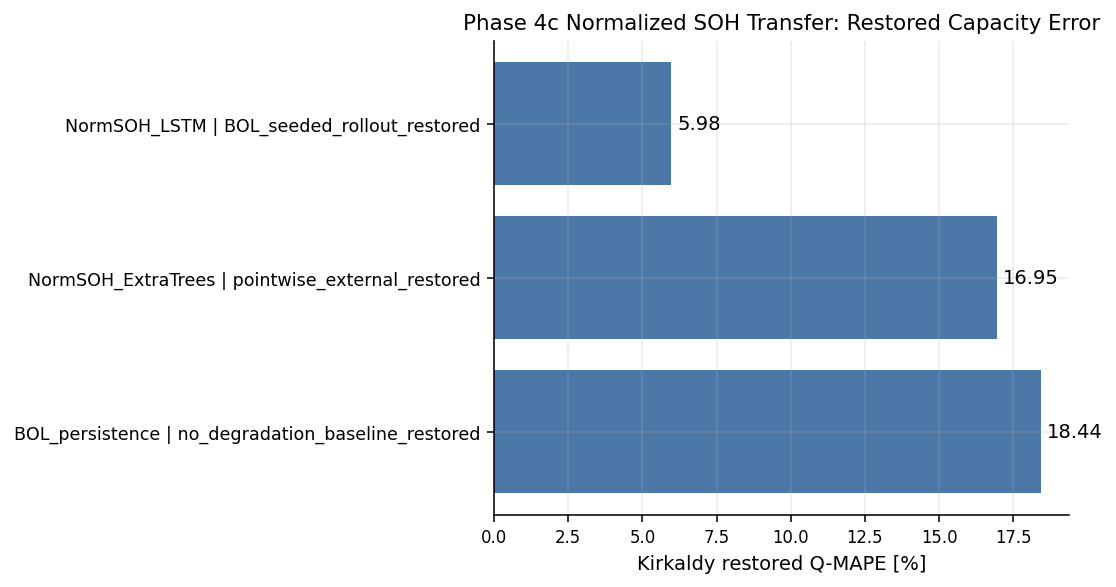

Saved: /kaggle/working/phase4c_normalized_soh_external_20260625_094714/figure_phase4c_soh_mape.png


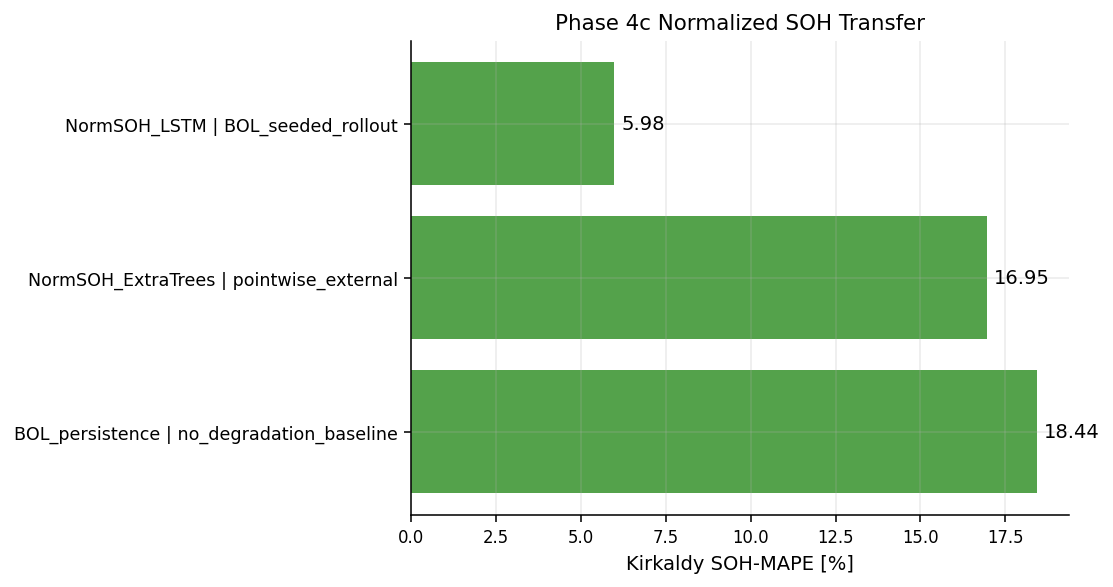

Saved: /kaggle/working/phase4c_normalized_soh_external_20260625_094714/figure_phase4c_kirkaldy_soh_rollout_trajectories.png


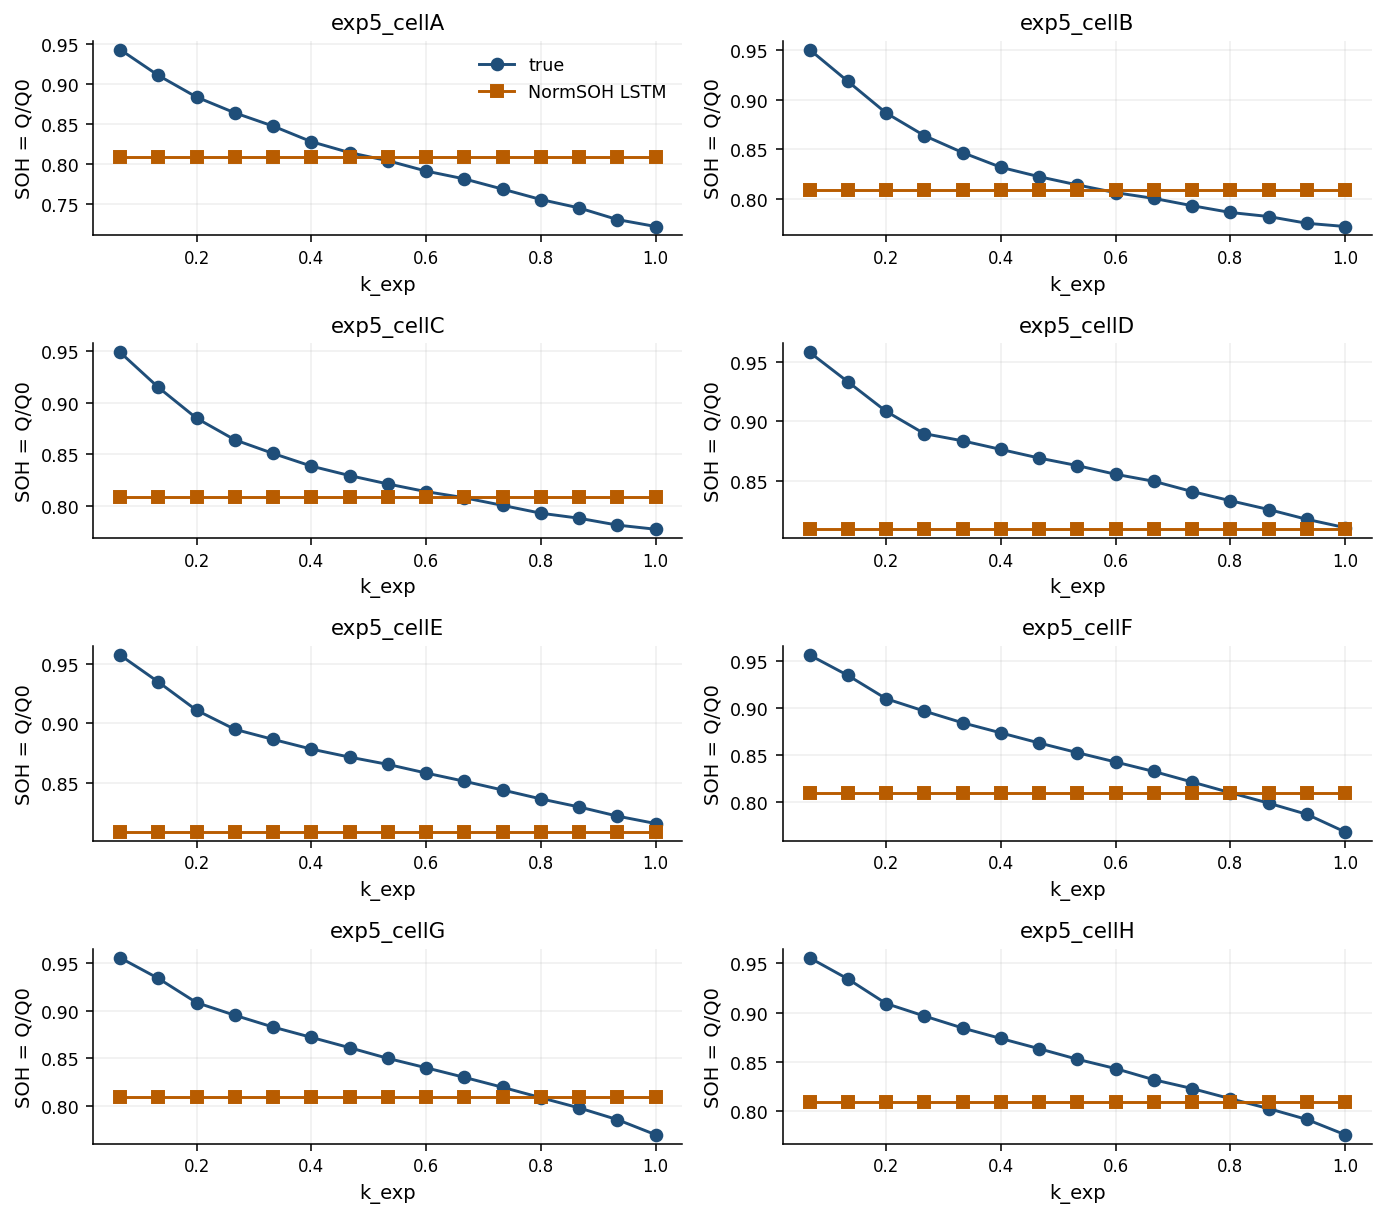

In [47]:
paper_rows = metrics_df[
    metrics_df["Split"].eq("Kirkaldy_external")
    & metrics_df["Target"].isin(["SOH", "Q"])
].copy()
paper_rows["Rank_in_target"] = paper_rows.groupby("Target")["MAPE"].rank(method="min")
paper_rows = paper_rows.sort_values(["Target", "MAPE"]).reset_index(drop=True)
paper_rows.to_csv(OUT_DIR / "phase4c_paper_normalized_external_table.csv", index=False)

claims = pd.DataFrame([
    {
        "Claim": "Capacity normalization directly tests whether Phase 4 failure was dominated by absolute capacity scale.",
        "Evidence": "The model predicts SOH=Q/Q0 and restores Q only after prediction, so 18650-vs-21700 nominal capacity is removed from the learning target.",
        "Paper_Use": "If external SOH-MAPE improves strongly versus raw-Q Phase 4, present normalization as the required correction for cross-format transfer.",
    },
    {
        "Claim": "Restored-Q MAPE remains the deployable reporting metric.",
        "Evidence": "Q_pred is reconstructed as SOH_pred*Q0 for each Kirkaldy cell.",
        "Paper_Use": "Report both SOH-MAPE and restored Q-MAPE; do not compare normalized SOH-MAPE directly to raw-Q Phase 1 MAPE without explaining the target change.",
    },
    {
        "Claim": "A BOL persistence baseline is necessary.",
        "Evidence": "Kirkaldy cells may degrade slowly across the sampled RPT range, so SOH=1 can be deceptively competitive.",
        "Paper_Use": "A normalized model is useful only if it beats the no-degradation baseline on external SOH/Q metrics.",
    },
])
claims.to_csv(OUT_DIR / "phase4c_normalization_claims.csv", index=False)

print_section("Paper Table")
display(paper_rows)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)


fig, ax = plt.subplots(figsize=(8.0, 4.3))
plot = paper_rows[paper_rows["Target"].eq("Q")].sort_values("MAPE")
ax.barh(plot["Model"] + " | " + plot["Protocol"], plot["MAPE"], color="#4C78A8")
ax.invert_yaxis()
ax.set_xlabel("Kirkaldy restored Q-MAPE [%]")
ax.set_title("Phase 4c Normalized SOH Transfer: Restored Capacity Error")
for i, v in enumerate(plot["MAPE"]):
    ax.text(v + 0.2, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4c_restored_q_mape.png")
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.3))
plot = paper_rows[paper_rows["Target"].eq("SOH")].sort_values("MAPE")
ax.barh(plot["Model"] + " | " + plot["Protocol"], plot["MAPE"], color="#54A24B")
ax.invert_yaxis()
ax.set_xlabel("Kirkaldy SOH-MAPE [%]")
ax.set_title("Phase 4c Normalized SOH Transfer")
for i, v in enumerate(plot["MAPE"]):
    ax.text(v + 0.2, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4c_soh_mape.png")
plt.show()

cells = list(kirk_rollout["cell_key"].drop_duplicates())[:8]
fig, axes = plt.subplots(math.ceil(len(cells) / 2), 2, figsize=(10, max(4, 2.2 * math.ceil(len(cells) / 2))), squeeze=False)
for ax, cell in zip(axes.ravel(), cells):
    g = kirk_rollout[kirk_rollout["cell_key"].eq(cell)].sort_values("k_exp")
    ax.plot(g["k_exp"], g["SOH_true"], marker="o", label="true", color="#1F4E79")
    ax.plot(g["k_exp"], g["SOH_pred"], marker="s", label="NormSOH LSTM", color="#B85C00")
    ax.set_title(cell)
    ax.set_xlabel("k_exp")
    ax.set_ylabel("SOH = Q/Q0")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(cells):]:
    ax.axis("off")
axes.ravel()[0].legend(frameon=False)
savefig("figure_phase4c_kirkaldy_soh_rollout_trajectories.png")
plt.show()


## 10. Export


In [48]:
manifest = {
    "run_tag": RUN_TAG,
    "pack_dir": str(PACK_DIR),
    "kirk_root": str(KIRK_ROOT),
    "seq_len": SEQ_LEN,
    "base_features": BASE_FEATS,
    "sequence_features": SEQ_FEATURES,
    "targets": TARGETS,
    "run_fast": RUN_FAST,
    "epochs_requested": EPOCHS,
    "epochs_run": int(pd.DataFrame(history)["epoch"].max()),
    "outputs": sorted([p.name for p in OUT_DIR.iterdir()]),
}
(OUT_DIR / "phase4c_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT_DIR))

print_section("Done")
print("Output directory:", OUT_DIR)
print("Zip:", zip_path)
print("Files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)



Done
Output directory: /kaggle/working/phase4c_normalized_soh_external_20260625_094714
Zip: /kaggle/working/phase4c_normalized_soh_external_20260625_094714.zip
Files:
 - figure_phase4c_kirkaldy_soh_rollout_trajectories.png
 - figure_phase4c_restored_q_mape.png
 - figure_phase4c_soh_mape.png
 - phase4c_kirkaldy_extratrees_normalized_predictions.csv
 - phase4c_kirkaldy_normalized_features.csv
 - phase4c_kirkaldy_normalized_rollout_predictions.csv
 - phase4c_kirkaldy_parse_errors.csv
 - phase4c_luh_test_rollout_predictions.csv
 - phase4c_luh_test_teacher_predictions.csv
 - phase4c_manifest.json
 - phase4c_normalization_claims.csv
 - phase4c_normalized_external_metrics_summary.csv
 - phase4c_normalized_lstm_training_history.csv
 - phase4c_paper_normalized_external_table.csv
